# Sample Sankey
- sankey plot to display bks set of clb samples
- goal: use sankey to display fates over time of tagged colonies and samples that coincide with nutrient collection dates
- source of code: sctld-SampleSankey.ipynb

In [206]:
library(dplyr)
library(tidyverse)
library(ggplot2)
library(tidyr)
library(purrr)
library(stringr)
library(reshape2) 
library(ggsankey)

In [207]:
colony_all <- read_csv("/Users/brookesienkiewicz/Documents/sctld/SCTLD_samples/Sample_Data/CBC_ColonyData.csv", show_col_types = FALSE)
sctld_samples <- read.csv("/Users/brookesienkiewicz/Documents/sctld/SCTLD_samples/Sample_Data/CBC_samples.csv")

New names:
• `` -> `...1`


In [208]:
# add colony ids to all dfs
add_colonyid <- function(df) {
    # get transect # 
    df$transect_id <- paste0('T',df$TransectNum)
    # make colony id 
    df$colony_id <- paste(df$transect_id, df$NewTagNum, df$Species,
                                 sep = "_")
    return(df)
}

# apply 
sctld_samples<-add_colonyid(sctld_samples)
colony_all <- add_colonyid(colony_all)

In [209]:
unique(sctld_samples$Sample_type)
unique(sctld_samples$Month_year)

[1] "Core_frozen"   "Core_RNAlater" "Core_EtOH"     "Probiotics"   
[5] "Immune"        "TEM"           ""              "Syringe"

[1] 122022  92023  52022 112023  42024 102019  62019 122023  12024  22024
[11]  62024  82024  62025

In [210]:
sctld_samples %>%
    filter(colony_id == 'T1_5_SSID')
# samples present in jun 2025 

Month_year,Country,Location,CollectionDate,Transect,TransectNum,OldTagNum,NewTagNum,Species,Time_sampled,⋯,SampleNum,Health_status,Sampling_notes,Tubelabel_species,Sample_physical_location,Extraction_physical_location,Date_sequenced,Notes,transect_id,colony_id
<int>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
92023,BEL,CBC,9/27/23,CBC30N,1,,5,SSID,,⋯,188,Diseased_Tissue,,092023_BEL_CBC_T1_188_SSID,UML_NARWHAL_R1_B10,UML_NARWHAL_R2_B11,,,T1,T1_5_SSID
92023,BEL,CBC,9/27/23,CBC30N,1,,5,SSID,,⋯,189,Diseased_Margin,,092023_BEL_CBC_T1_189_SSID,UML_NARWHAL_R1_B10,,,,T1,T1_5_SSID
92023,BEL,CBC,9/27/23,CBC30N,1,,5,SSID,,⋯,236,Diseased_Tissue,,092023_BEL_CBC_T1_236_SSID,,,,,T1,T1_5_SSID
92023,BEL,CBC,9/27/23,CBC30N,1,,5,SSID,,⋯,237,Diseased_Margin,,092023_BEL_CBC_T1_237_SSID,,,,,T1,T1_5_SSID
52022,BEL,CBC,5/21/22,CBC30N,1,394,5,SSID,,⋯,22,Diseased_Margin,,052022_BEL_CBC_T1_22_SSID,SERC,,,,T1,T1_5_SSID
52022,BEL,CBC,5/21/22,CBC30N,1,394,5,SSID,,⋯,25,Diseased_Tissue,,052022_BEL_CBC_T1_25_SSID,SERC,,,,T1,T1_5_SSID
52022,BEL,CBC,5/21/22,CBC30N,1,394,5,SSID,,⋯,8,Diseased_Margin,,052022_BEL_CBC_T1_8_SSID,UML_NARWHAL_R1_B3,,,,T1,T1_5_SSID
52022,BEL,CBC,5/21/22,CBC30N,1,394,5,SSID,,⋯,9,Diseased_Tissue,,052022_BEL_CBC_T1_9_SSID,UML_NARWHAL_R1_B3,,,,T1,T1_5_SSID
62019,BEL,CBC,6/24/19,CBC30N,1,394,5,SSID,,⋯,23,Healthy,,062019_BEL_CBC_T1_23_SSID,UML_NARWHAL_R1_B1,,,,T1,T1_5_SSID


In [211]:
# list of nutrient sampling dates 
nut_dates <- as.integer(c(12024,42024, 62024,82024,62025))

In [212]:
#filter sample data for nutrient sampling dates (& UML DNA samples only)
samples<-sctld_samples %>%
    filter(Sample_type == 'Core_RNAlater') %>%
    filter(Month_year %in% nut_dates)
nrow(samples)

# filter colony data to match sequence list 
colony <- colony_all %>%
    filter(colony_id %in% samples$colony_id)
length(unique(colony$colony_id))

# 148 unique colonies - 463 total samples

[1] 463

[1] 151

In [213]:
# check after filtering 
samples %>%
    filter(colony_id == 'T1_5_SSID')
# still present 

Month_year,Country,Location,CollectionDate,Transect,TransectNum,OldTagNum,NewTagNum,Species,Time_sampled,⋯,SampleNum,Health_status,Sampling_notes,Tubelabel_species,Sample_physical_location,Extraction_physical_location,Date_sequenced,Notes,transect_id,colony_id
<int>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
42024,BEL,CBC,4/25/24,CBC30N,1,,5,SSID,9:48,⋯,933,Diseased_Tissue,"90% CTL/ old mort , 5% DC- lots of webbing and sloughing",042024_BEL_CBC_T1_933_SSID,UML_NARWHAL_R5_B24,UML_NARWHAL_R2_B11,,,T1,T1_5_SSID
42024,BEL,CBC,4/25/24,CBC30N,1,,5,SSID,9:48,⋯,934,Diseased_Margin,"90% CTL/ old mort , 5% DC- lots of webbing and sloughing",042024_BEL_CBC_T1_934_SSID,UML_NARWHAL_R5_B24,,,,T1,T1_5_SSID
62025,BEL,CBC,5/30/25,CBC30N,1,,5,SSID,9:22,⋯,1621,Diseased_Tissue,,062025_BEL_CBC_T1_1621_SSID,UML_Narwhal_R3_B43,,,,T1,T1_5_SSID
62025,BEL,CBC,5/30/25,CBC30N,1,,5,SSID,9:22,⋯,1622,Diseased_Margin,,062025_BEL_CBC_T1_1622_SSID,UML_Narwhal_R3_B43,,,,T1,T1_5_SSID


In [214]:
colnames(colony)

[1] "...1"                     "Date_InitialTag"         
 [3] "Transect"                 "TransectNum"             
 [5] "OldTagNum"                "NewTagNum"               
 [7] "Species"                  "Meter"                   
 [9] "Meters_90"                "Direction"               
[11] "Size_Class"               "MaxDiameter"             
[13] "Height"                   "Date_DocumentedDisease"  
[15] "Date_DocumentedMortality" "Notes_062019"            
[17] "062019_Condition"         "062019_Percentage"       
[19] "Notes_052022"             "052022_Condition"        
[21] "052022_Percentage"        "Notes_122022"            
[23] "122022_Condition"         "122022_Percentage"       
[25] "Notes_092023"             "092023_Condition"        
[27] "092023_Percentage"        "Notes_112023"            
[29] "112023_Condition"         "112023_Percentage"       
[31] "Notes_122023"             "122023_Condition"        
[33] "122023_Percentage"        "Notes_012024"            
[35] "012024_Condition"         "012024_Percentage"       
[37] "Notes_022024"             "022024_Condition"        
[39] "022024_Percentage"        "Notes_042024"            
[41] "042024_Condition"         "042024_Percentage"       
[43] "062024_Condition"         "062024_Percentage"       
[45] "Notes_062024"             "082024_Condition"        
[47] "082024_Percentage"        "Notes_082024"            
[49] "122024_Condition"         "122024_Percentage"       
[51] "Notes_122024"             "062025_Condition"        
[53] "062025_Percentage"        "Notes_062025"            
[55] "immune_y/n"               "checked_colonies"        
[57] "transect_id"              "colony_id"

In [215]:
# convert condition columns in colony data to month year format 

## change colnames into dates 
# list columns with dates
tf <- grepl('Condition', colnames(colony))
date_col <- colnames(colony)[tf]

# get rid of 'condition' to have col names just contain the date
new_col<-gsub('_Condition', '',date_col)

# convert to mmyydd date format before final date conversion 
formatted_dates <- as.Date(paste0(new_col, "01"), format = "%m%Y%d")

# Format the dates as "Nov 2023", etc.
formatted_labels <- format(formatted_dates, "%b %Y")

# Replace the column names in clb_colony with the formatted labels
colnames(colony)[tf] <- formatted_labels 

# #this is the new list of condiiton columns to use going forward
sample_dates <- c('Jan 2024','Apr 2024','Jun 2024','Aug 2024','Jun 2025')

In [216]:
formatted_dates

[1] "2019-06-01" "2022-05-01" "2022-12-01" "2023-09-01" "2023-11-01"
 [6] "2023-12-01" "2024-01-01" "2024-02-01" "2024-04-01" "2024-06-01"
[11] "2024-08-01" "2024-12-01" "2025-06-01"

In [217]:
# filter colony data for these dates
colony <- colony %>%
    select(colony_id, Species, any_of(sample_dates))

In [218]:
colnames(colony)

[1] "colony_id" "Species"   "Jan 2024"  "Apr 2024"  "Jun 2024"  "Aug 2024" 
[7] "Jun 2025"

In [219]:
unique(samples$Month_year)

[1] 42024 12024 62024 82024 62025

In [220]:
# repeat date formatting for sample data 

# add leading 0 
leading <- sprintf('%06d',unique(samples$Month_year))

# convert to mmyydd date format before final date conversion 
formatted_dates <- as.Date(paste0(leading, "01"), format = "%m%Y%d")
formatted_dates

# Format the dates as "Nov 2023", etc.
formatted_labels <- format(formatted_dates, "%b %Y")

# Set names  
label_lookup <- setNames(formatted_labels, unique(samples$Month_year))
label_lookup

# Replace the month_year values with the formatted dates 
samples$Month_year <- label_lookup[as.character(samples$Month_year)]
unique(samples$Month_year)

[1] "2024-04-01" "2024-01-01" "2024-06-01" "2024-08-01" "2025-06-01"

42024      12024      62024      82024      62025 
"Apr 2024" "Jan 2024" "Jun 2024" "Aug 2024" "Jun 2025"

[1] "Apr 2024" "Jan 2024" "Jun 2024" "Aug 2024" "Jun 2025"

In [221]:
# check after reformatting dates
samples %>%
    filter(colony_id == 'T1_5_SSID')

Month_year,Country,Location,CollectionDate,Transect,TransectNum,OldTagNum,NewTagNum,Species,Time_sampled,⋯,SampleNum,Health_status,Sampling_notes,Tubelabel_species,Sample_physical_location,Extraction_physical_location,Date_sequenced,Notes,transect_id,colony_id
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Apr 2024,BEL,CBC,4/25/24,CBC30N,1,,5,SSID,9:48,⋯,933,Diseased_Tissue,"90% CTL/ old mort , 5% DC- lots of webbing and sloughing",042024_BEL_CBC_T1_933_SSID,UML_NARWHAL_R5_B24,UML_NARWHAL_R2_B11,,,T1,T1_5_SSID
Apr 2024,BEL,CBC,4/25/24,CBC30N,1,,5,SSID,9:48,⋯,934,Diseased_Margin,"90% CTL/ old mort , 5% DC- lots of webbing and sloughing",042024_BEL_CBC_T1_934_SSID,UML_NARWHAL_R5_B24,,,,T1,T1_5_SSID
Jun 2025,BEL,CBC,5/30/25,CBC30N,1,,5,SSID,9:22,⋯,1621,Diseased_Tissue,,062025_BEL_CBC_T1_1621_SSID,UML_Narwhal_R3_B43,,,,T1,T1_5_SSID
Jun 2025,BEL,CBC,5/30/25,CBC30N,1,,5,SSID,9:22,⋯,1622,Diseased_Margin,,062025_BEL_CBC_T1_1622_SSID,UML_Narwhal_R3_B43,,,,T1,T1_5_SSID


In [78]:
lapply(sample_dates, function(col) {
  unique(colony[[col]])
})

[[1]]
 [1] "Diseased"            "CLP,CLB"             "Healthy"            
 [4] "CLP"                 "CLP,DC"              "Not_Visited"        
 [7] "CLB"                 "Diseased_Other, CLP" "DC"                 
[10] NA                   

[[2]]
[1] "Diseased"       "Not_Visited"    "Healthy"        "Diseased, CLP" 
[5] "CLP"            "Diseased_Other" "DC"             "Not_visited"   

[[3]]
[1] "Not_Visited"    "Healthy"        "Diseased"       "DC"            
[5] "Diseased_Other" "Not_visited"    "not_visited"   

[[4]]
[1] "Not_Visited"    "Healthy"        "Diseased"       "Dead"          
[5] "CLP"            "Diseased_Other" "DC"             "CLB"           

[[5]]
[1] "Diseased"    "Healthy"     "Dead"        "CLP"         "CLB"        
[6] "Not_visited" NA

In [79]:
# conditions to change 

# replace multiple conditions 
# replace NAs 
colony<-colony %>%
  mutate(across(all_of(sample_dates), ~ case_when(
      # make not visited consistent 
    grepl('Not_visited', ., ignore.case=TRUE) ~ 'Not_Visited',
      # clp & clb -> clb 
    . == 'CLP,CLB' ~ 'CLB',
      # clp, dc or dc-> clp 
    . == 'CLB,DC' ~ 'CLB',
    . == 'CLP,DC' ~ 'CLP',
      # ssids are the only ones with DC so just going to make that clp cuz its likely bleaching..can investigate more thoroughly later 
    . == 'DC' ~ 'CLP',
      # if disease or diseased_other & clp -> just make diseased 
    . == 'Diseased_Other, CLP' ~ 'Diseased',
    . == 'Diseased, CLP' ~ 'Diseased',
      # all NAs are T6 that had not been tagged in Jan 2024 
    is.na(.) ~ 'Not_yet_tagged',
    TRUE ~ .
  )))

In [104]:
colony %>%
    filter(colony_id == 'T1_5_SSID')
samples %>%
    filter(colony_id == 'T1_5_SSID')

colony_id,Species,Jan 2024,Apr 2024,Jun 2024,Aug 2024,Jun 2025
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
T1_5_SSID,SSID,Diseased,Diseased,Not_Visited,Not_Visited,Diseased


Month_year,Country,Location,CollectionDate,Transect,TransectNum,OldTagNum,NewTagNum,Species,Time_sampled,⋯,Health_status,Sampling_notes,Tubelabel_species,Sample_physical_location,Extraction_physical_location,Date_sequenced,Notes,transect_id,colony_id,dates
<fct>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<date>
Apr 2024,BEL,CBC,4/25/24,CBC30N,1,,5,SSID,9:48,⋯,Diseased_Tissue,"90% CTL/ old mort , 5% DC- lots of webbing and sloughing",042024_BEL_CBC_T1_933_SSID,UML_NARWHAL_R5_B24,UML_NARWHAL_R2_B11,,,T1,T1_5_SSID,2024-04-25
Apr 2024,BEL,CBC,4/25/24,CBC30N,1,,5,SSID,9:48,⋯,Diseased_Margin,"90% CTL/ old mort , 5% DC- lots of webbing and sloughing",042024_BEL_CBC_T1_934_SSID,UML_NARWHAL_R5_B24,,,,T1,T1_5_SSID,2024-04-25
NA,BEL,CBC,5/30/25,CBC30N,1,,5,SSID,9:22,⋯,Diseased_Tissue,,062025_BEL_CBC_T1_1621_SSID,UML_Narwhal_R3_B43,,,,T1,T1_5_SSID,2025-05-30
NA,BEL,CBC,5/30/25,CBC30N,1,,5,SSID,9:22,⋯,Diseased_Margin,,062025_BEL_CBC_T1_1622_SSID,UML_Narwhal_R3_B43,,,,T1,T1_5_SSID,2025-05-30


In [80]:
sankeydf <- data.frame()
for(id in unique(colony$colony_id)){
    # print(id)
    #create dfs for individual colonies 
    df <- colony %>%
        filter(colony_id == id)
    # print(df)

    # pivot longer
    sankdf <- df %>% 
     make_long(all_of(sample_dates)) %>%
     mutate(colony_id = id) 
    # print("sankdf")
    # print(sankdf)

    # combine into 1 df
   sankeydf <- sankeydf %>%
     bind_rows(sankdf)
    # print("sankeydf")
    # print(sankeydf)
}
# print commands are for troubleshooting

In [81]:
testid = 'T1_2_PAST' 
tail(strsplit(testid, "_")[[1]], 1)

[1] "PAST"

In [82]:
# add species labels and sample statuses for each colony id 

# filter samples to match sankeydf format 
sampledf <- samples %>% 
    select(colony_id, Month_year, Health_status) %>%
    rename(x = Month_year,
          sample_condition = Health_status)

# merge
sankey <- sankeydf %>%
    left_join(sampledf,
         # match sample conditions to 'x' (first time point in the set) 
             by = c('colony_id','x')) %>%
        # add species grouping based on colony id 
    rowwise() %>%    
    mutate(species = tail(strsplit(colony_id, "_")[[1]], 1))

head(sankey,10)

x,node,next_x,next_node,colony_id,sample_condition,species
<fct>,<chr>,<fct>,<chr>,<chr>,<chr>,<chr>
Jan 2024,Diseased,Apr 2024,Diseased,T1_1_SSID,NA,SSID
Apr 2024,Diseased,Jun 2024,Not_Visited,T1_1_SSID,Diseased_Margin,SSID
Jun 2024,Not_Visited,Aug 2024,Not_Visited,T1_1_SSID,NA,SSID
Aug 2024,Not_Visited,Jun 2025,Diseased,T1_1_SSID,NA,SSID
Jun 2025,Diseased,NA,NA,T1_1_SSID,NA,SSID
Jan 2024,CLB,Apr 2024,Not_Visited,T1_2_PAST,NA,PAST
Apr 2024,Not_Visited,Jun 2024,Healthy,T1_2_PAST,NA,PAST
Jun 2024,Healthy,Aug 2024,Healthy,T1_2_PAST,Healthy,PAST
Aug 2024,Healthy,Jun 2025,Healthy,T1_2_PAST,Healthy,PAST


In [83]:
unique(sankey$node)

[1] "Diseased"       "Not_Visited"    "CLB"            "Healthy"       
[5] "Dead"           "CLP"            "Diseased_Other" "Not_yet_tagged"

In [84]:
# write_csv(x = sankey, file = 'sankeydf.csv')

In [85]:
sank_colors = c('Dead'='tomato3',
                'Healthy'='palegreen3',
                'CLP'='lightgoldenrod2',
                'CLB'='cadetblue1',
                 'DC' = 'thistle2',
                 'Diseased' = 'salmon1',
                 'Diseased_Other' = 'coral3',
                 'Not_Visited' = 'honeydew2',
                 'Not_yet_tagged' = 'gray78')


# sank_colors = c('Dead'='black','Healthy'='forestgreen',
#                  'DC' = 'blueviolet',
#                  'Diseased' = 'firebrick',
#                  'Diseased_Other' = 'coral3',
#                  'Not_Visited' = 'gray30',
#                  'Unknown' = 'gray78')

In [86]:
options(repr.plot.width=12, repr.plot.height=10)

In [87]:
# investigate any dups 
# dupes <- mcav %>%
#   count(x, colony_id) %>%
#   filter(n > 1)
# dupes

# #remove 
# mcav <- mcav %>%
#   distinct(x, colony_id, .keep_all = TRUE)

# i dont think this ended up being necessary?

In [94]:
# list of immune-only sample dates
immune_dates <- c('Jan 2024', 'Jun 2024', 'Aug 2024')

# add back in immune category
sankey <- sankey %>%
  left_join(
    colony_all %>% select(colony_id, `immune_y/n`), 
    by = "colony_id"
  )

[1] "Missing samples:"
# A tibble: 37 × 4
   colony_id  x        node     `immune_y/n`
   <chr>      <fct>    <chr>    <chr>       
 1 T1_1_SSID  Jan 2024 Diseased n           
 2 T1_1_SSID  Jun 2025 Diseased n           
 3 T1_3_SSID  Jun 2025 Diseased y           
 4 T1_5_SSID  Jan 2024 Diseased n           
 5 T1_5_SSID  Jun 2025 Diseased n           
 6 T1_9_SSID  Jan 2024 Diseased n           
 7 T1_9_SSID  Jun 2025 Diseased n           
 8 T1_11_SSID Jan 2024 Diseased n           
 9 T1_11_SSID Jun 2025 Diseased n           
10 T1_16_SSID Jan 2024 Diseased n           
# ℹ 27 more rows


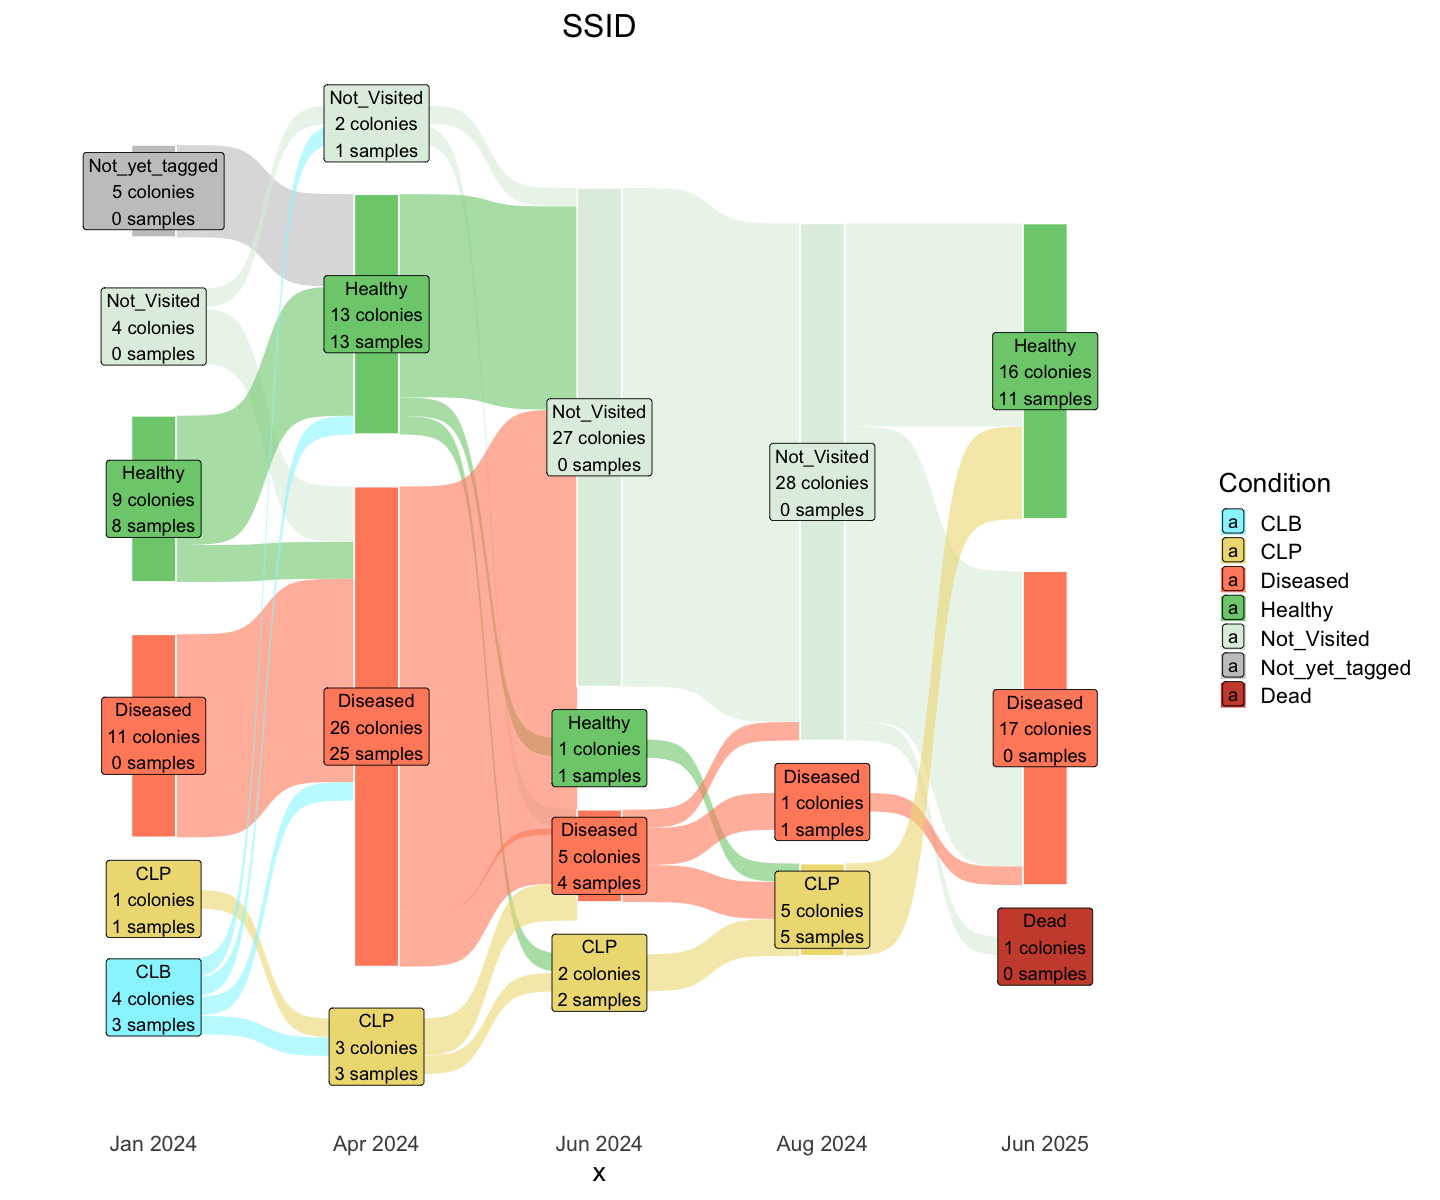

[1] "Missing samples:"
# A tibble: 15 × 4
   colony_id  x        node    `immune_y/n`
   <chr>      <fct>    <chr>   <chr>       
 1 T1_2_PAST  Jan 2024 CLB     y           
 2 T1_2_PAST  Jun 2025 Healthy y           
 3 T1_21_PAST Jun 2024 Healthy y           
 4 T2_47_PAST Jun 2025 Healthy n           
 5 T2_57_PAST Jun 2025 Healthy y           
 6 T2_63_PAST Jun 2025 Healthy y           
 7 T2_68_PAST Jun 2025 Healthy y           
 8 T3_7_PAST  Jan 2024 CLP     n           
 9 T3_10_PAST Jan 2024 Healthy y           
10 T3_13_PAST Jan 2024 Healthy n           
11 T3_13_PAST Jun 2025 Healthy n           
12 T3_18_PAST Jan 2024 Healthy n           
13 T3_18_PAST Jun 2025 Healthy n           
14 T3_34_PAST Jun 2025 Healthy y           
15 T5_42_PAST Apr 2024 Healthy n           


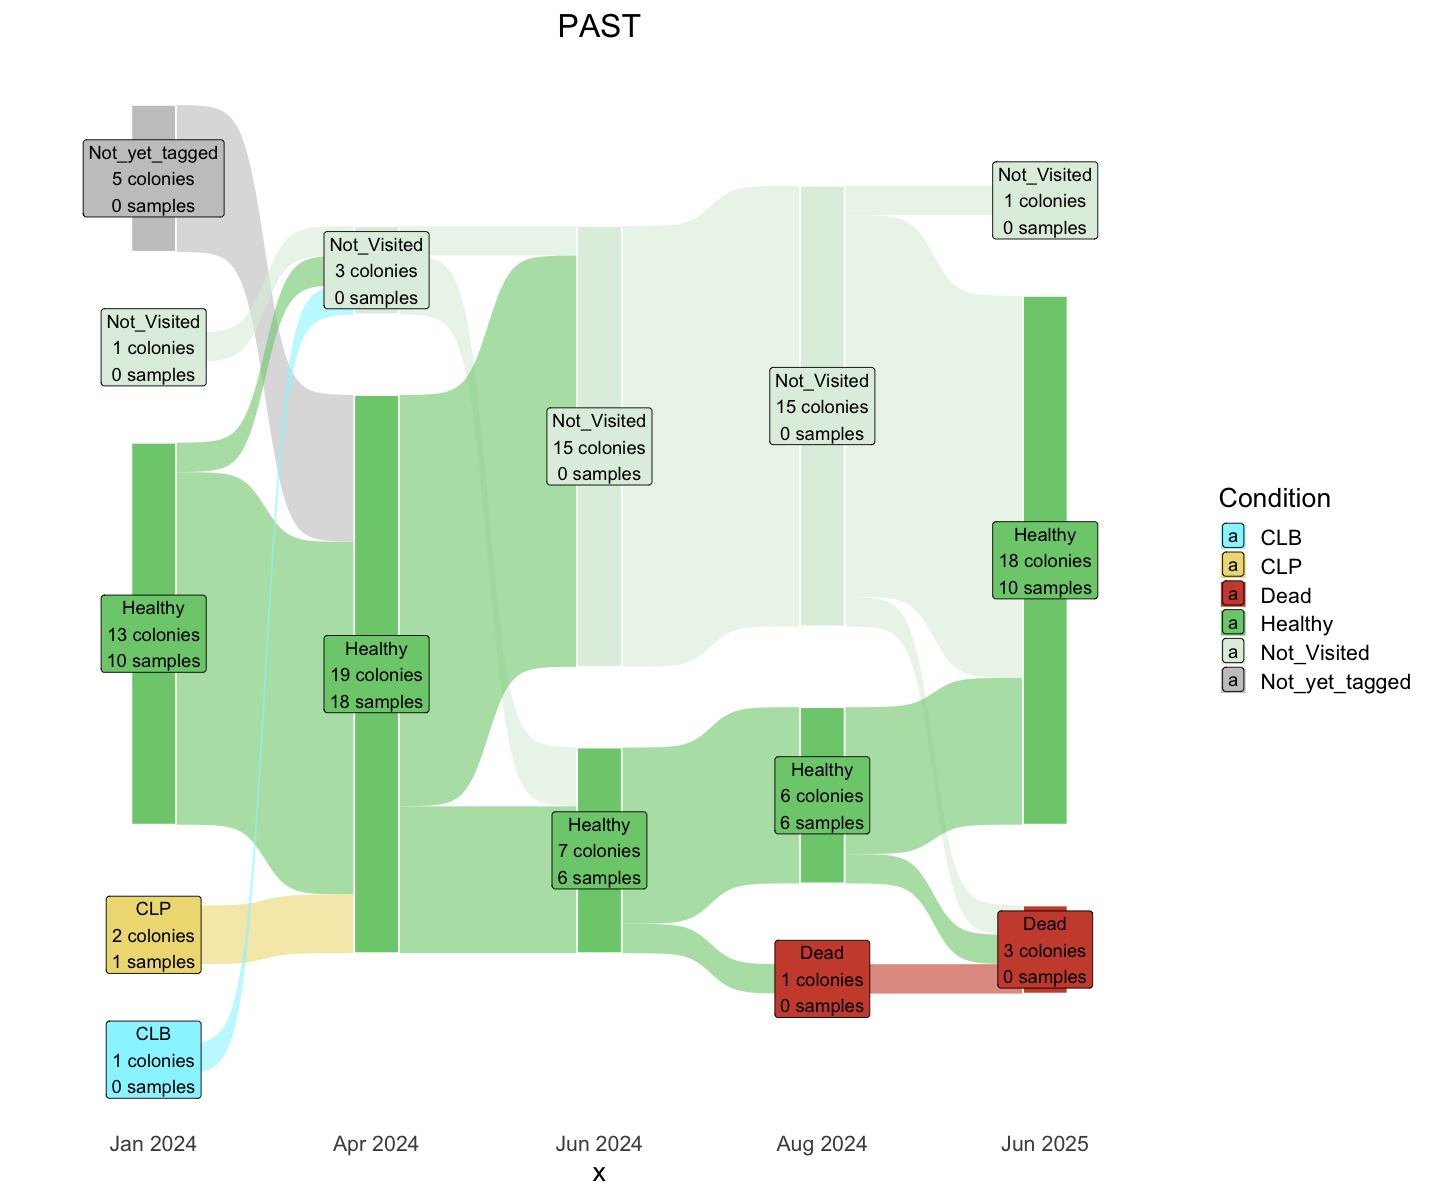

[1] "Missing samples:"
# A tibble: 17 × 4
   colony_id  x        node    `immune_y/n`
   <chr>      <fct>    <chr>   <chr>       
 1 T1_7_MCAV  Jan 2024 Healthy n           
 2 T1_24_MCAV Jun 2025 Healthy y           
 3 T2_53_MCAV Jun 2025 Healthy n           
 4 T2_55_MCAV Jun 2025 Healthy y           
 5 T2_59_MCAV Jan 2024 Healthy n           
 6 T2_59_MCAV Jun 2025 Healthy n           
 7 T2_60_MCAV Jun 2025 Healthy y           
 8 T2_69_MCAV Jun 2025 Healthy y           
 9 T3_2_MCAV  Jun 2025 Healthy y           
10 T3_14_MCAV Jun 2025 Healthy y           
11 T3_21_MCAV Jun 2025 Healthy y           
12 T3_71_MCAV Jan 2024 Healthy n           
13 T3_71_MCAV Jun 2025 Healthy n           
14 T4_28_MCAV Jan 2024 Healthy y           
15 T4_28_MCAV Jun 2025 Healthy y           
16 T4_30_MCAV Jun 2025 Healthy y           
17 T4_76_MCAV Jun 2025 Healthy y           


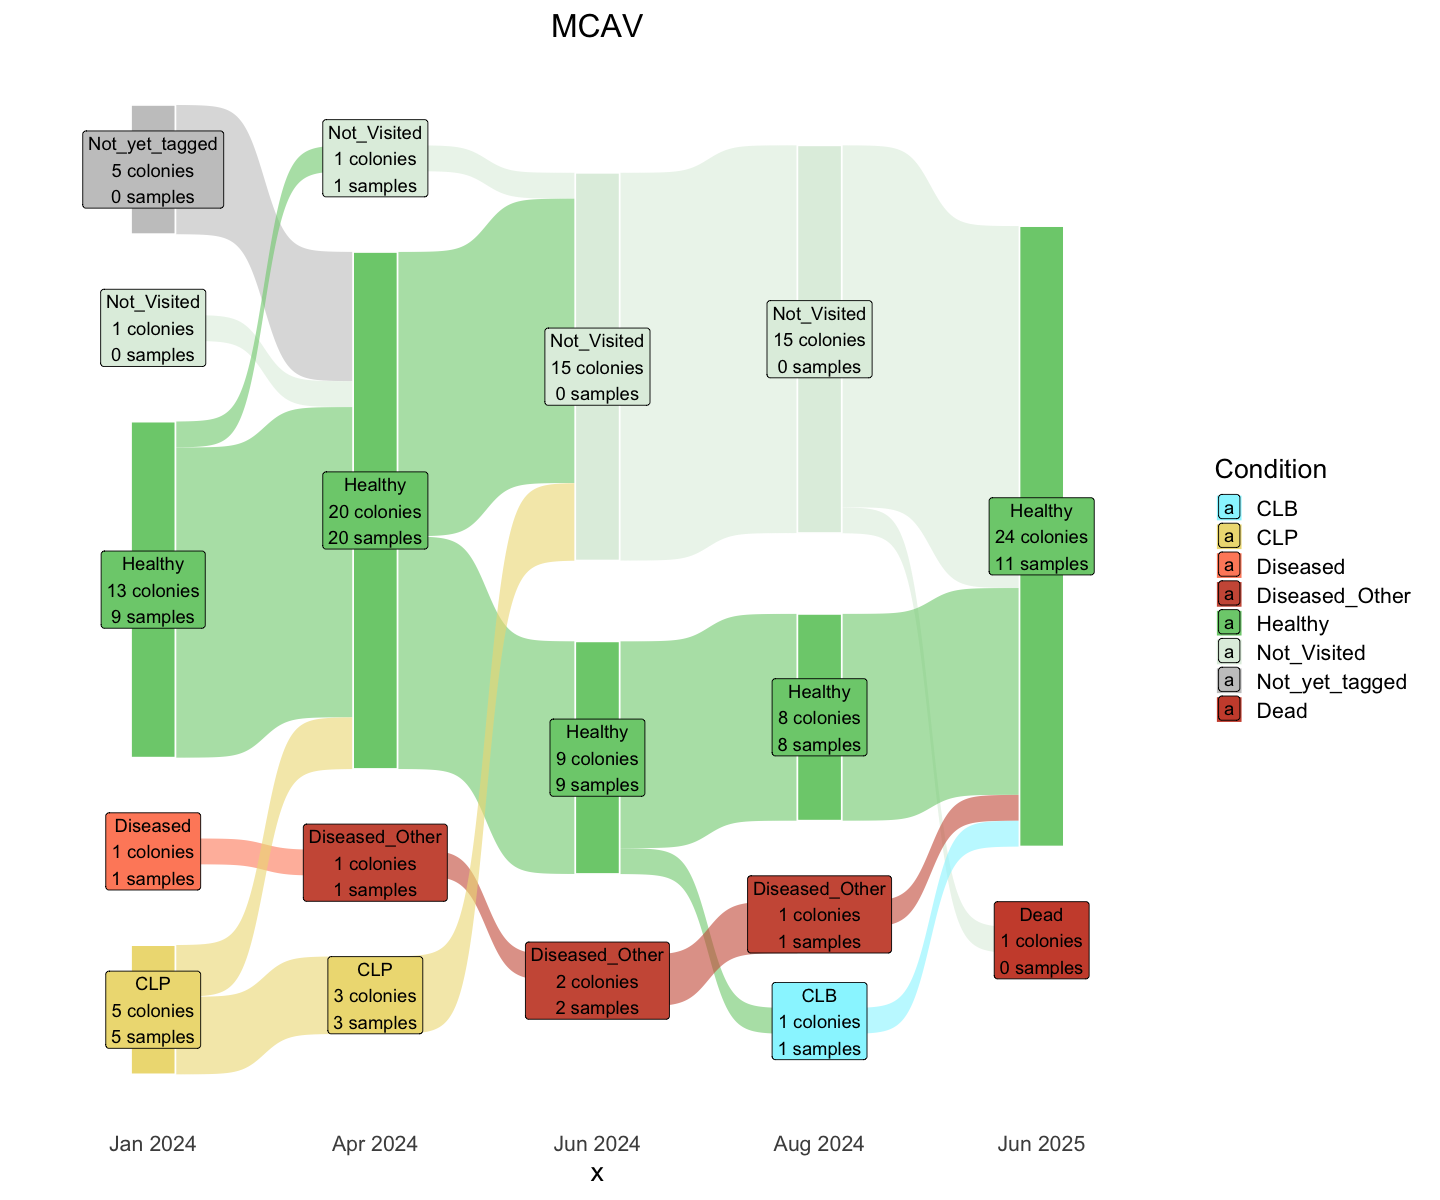

[1] "Missing samples:"
# A tibble: 12 × 4
   colony_id  x        node    `immune_y/n`
   <chr>      <fct>    <chr>   <chr>       
 1 T1_12_PSTR Jun 2025 Healthy y           
 2 T2_32_PSTR Jun 2025 Healthy n           
 3 T2_54_PSTR Jan 2024 CLP     n           
 4 T2_54_PSTR Jun 2025 Healthy n           
 5 T3_4_PSTR  Jan 2024 Healthy n           
 6 T3_4_PSTR  Jun 2025 Healthy n           
 7 T3_20_PSTR Jun 2025 Healthy y           
 8 T3_70_PSTR Jun 2025 CLP     y           
 9 T3_75_PSTR Jan 2024 CLP     n           
10 T3_75_PSTR Jun 2025 Healthy n           
11 T4_79_PSTR Jun 2025 Healthy y           
12 T4_98_PSTR Jun 2025 Healthy y           


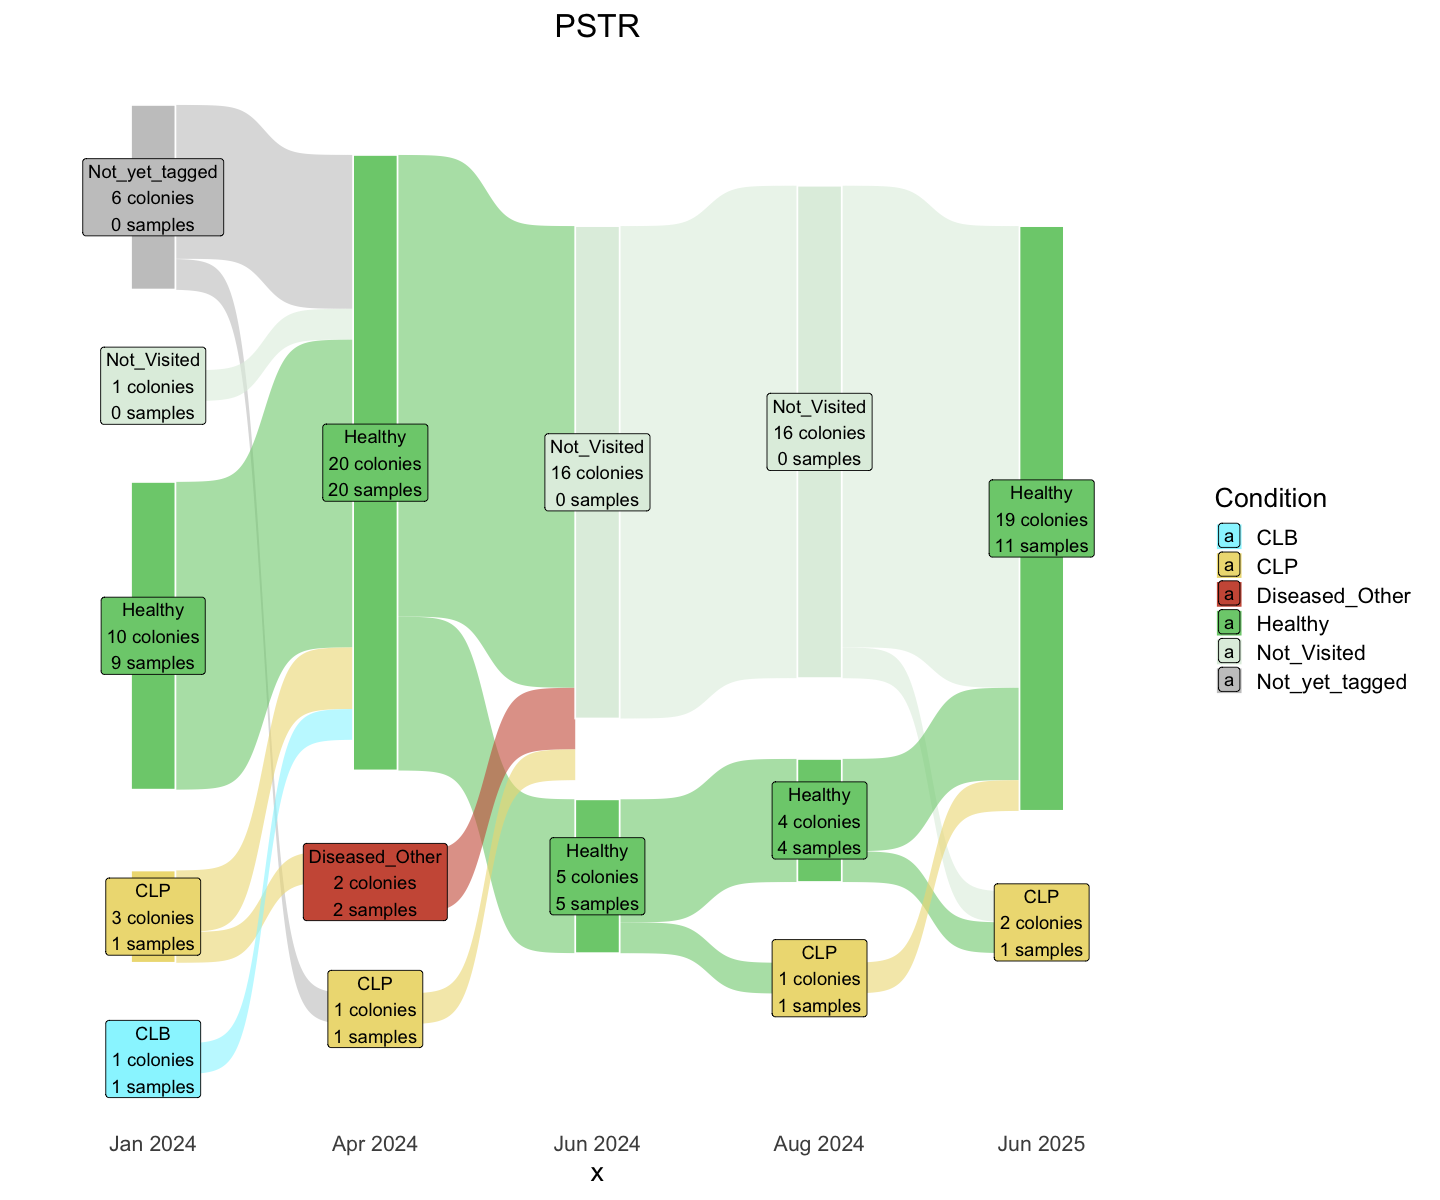

[1] "Missing samples:"
# A tibble: 12 × 4
   colony_id  x        node     `immune_y/n`
   <chr>      <fct>    <chr>    <chr>       
 1 T1_22_OANN Jan 2024 Diseased n           
 2 T1_22_OANN Jun 2025 CLP      n           
 3 T1_23_OANN Jan 2024 Healthy  n           
 4 T1_23_OANN Jun 2025 Healthy  n           
 5 T1_25_OANN Jun 2025 CLB      y           
 6 T2_30_OANN Jan 2024 CLP      n           
 7 T2_30_OANN Jun 2025 Healthy  n           
 8 T2_77_OANN Jun 2025 CLP      n           
 9 T3_68_OANN Jan 2024 Healthy  n           
10 T3_68_OANN Jun 2025 CLP      n           
11 T3_72_OANN Jan 2024 Healthy  n           
12 T3_72_OANN Jun 2025 CLP      n           


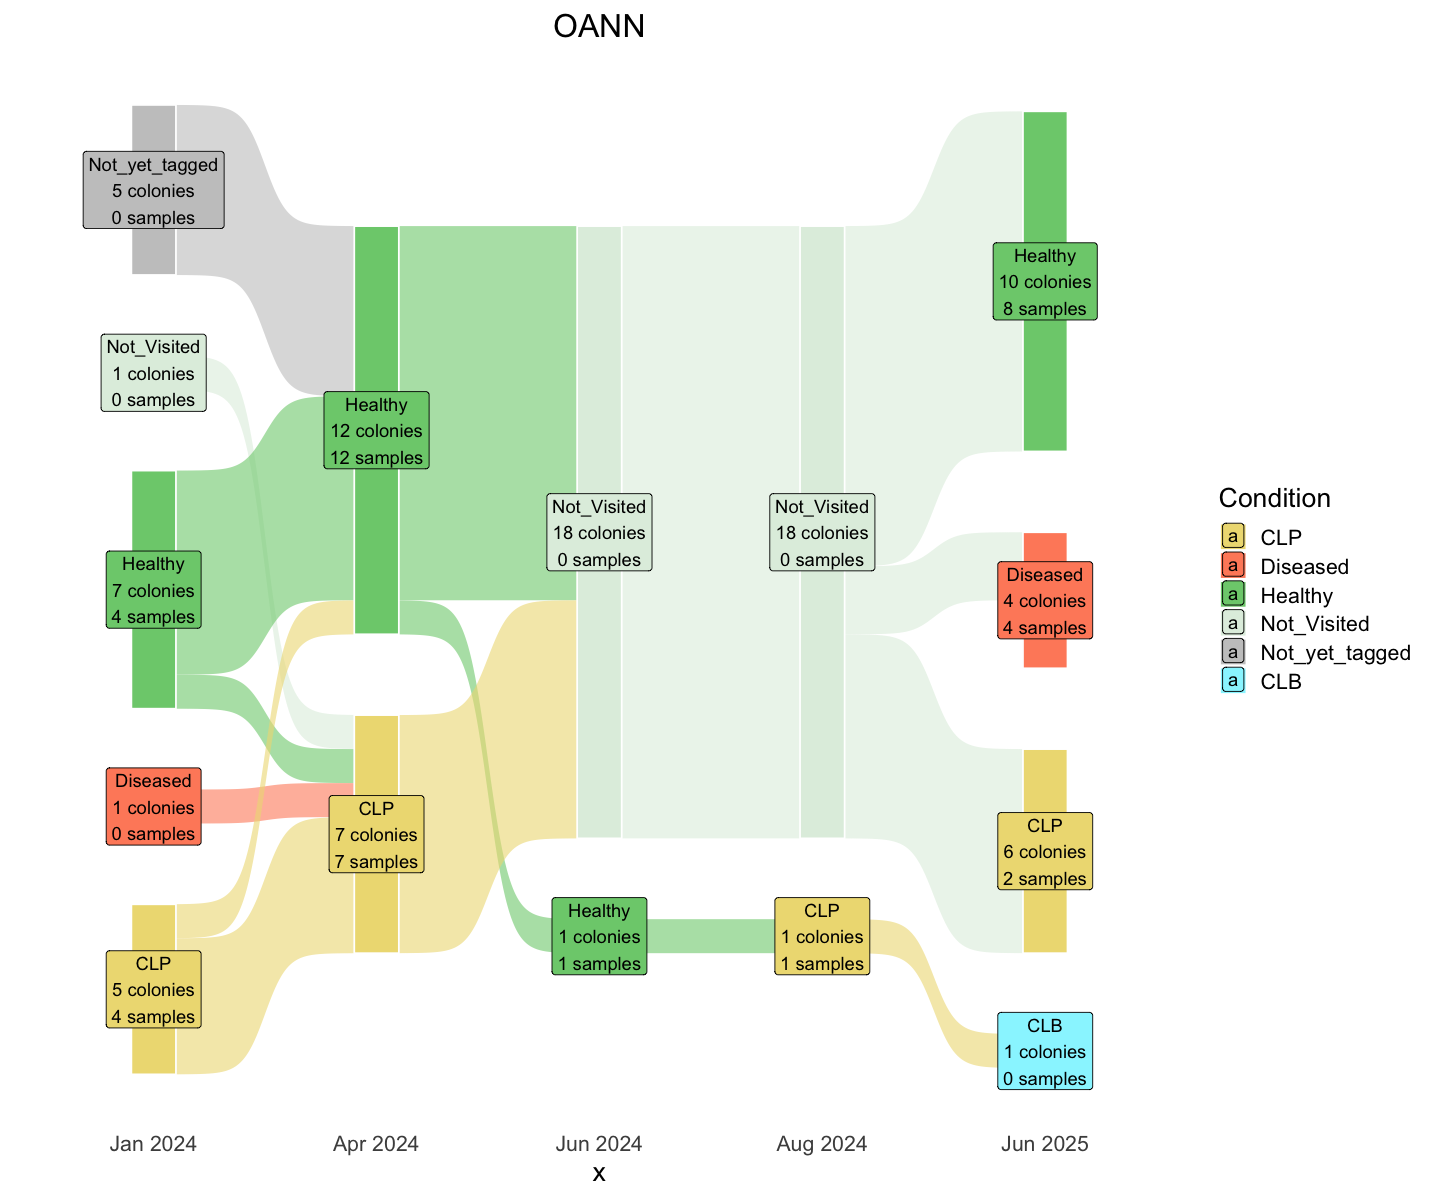

[1] "Missing samples:"
# A tibble: 16 × 4
   colony_id  x        node    `immune_y/n`
   <chr>      <fct>    <chr>   <chr>       
 1 T1_27_DLAB Jan 2024 Healthy n           
 2 T1_27_DLAB Jun 2025 Healthy n           
 3 T1_35_DLAB Jan 2024 CLP     n           
 4 T1_35_DLAB Jun 2025 Healthy n           
 5 T2_31_DLAB Jan 2024 Healthy n           
 6 T2_31_DLAB Jun 2025 Healthy n           
 7 T2_78_DLAB Jan 2024 Healthy n           
 8 T2_78_DLAB Jun 2025 Healthy n           
 9 T3_69_DLAB Jan 2024 CLP     n           
10 T3_69_DLAB Jun 2025 Healthy n           
11 T3_73_DLAB Jan 2024 Healthy n           
12 T3_73_DLAB Jun 2025 Healthy n           
13 T4_43_DLAB Jan 2024 Healthy n           
14 T4_43_DLAB Jun 2025 Healthy n           
15 T4_93_DLAB Jan 2024 Healthy n           
16 T4_93_DLAB Jun 2025 Healthy n           


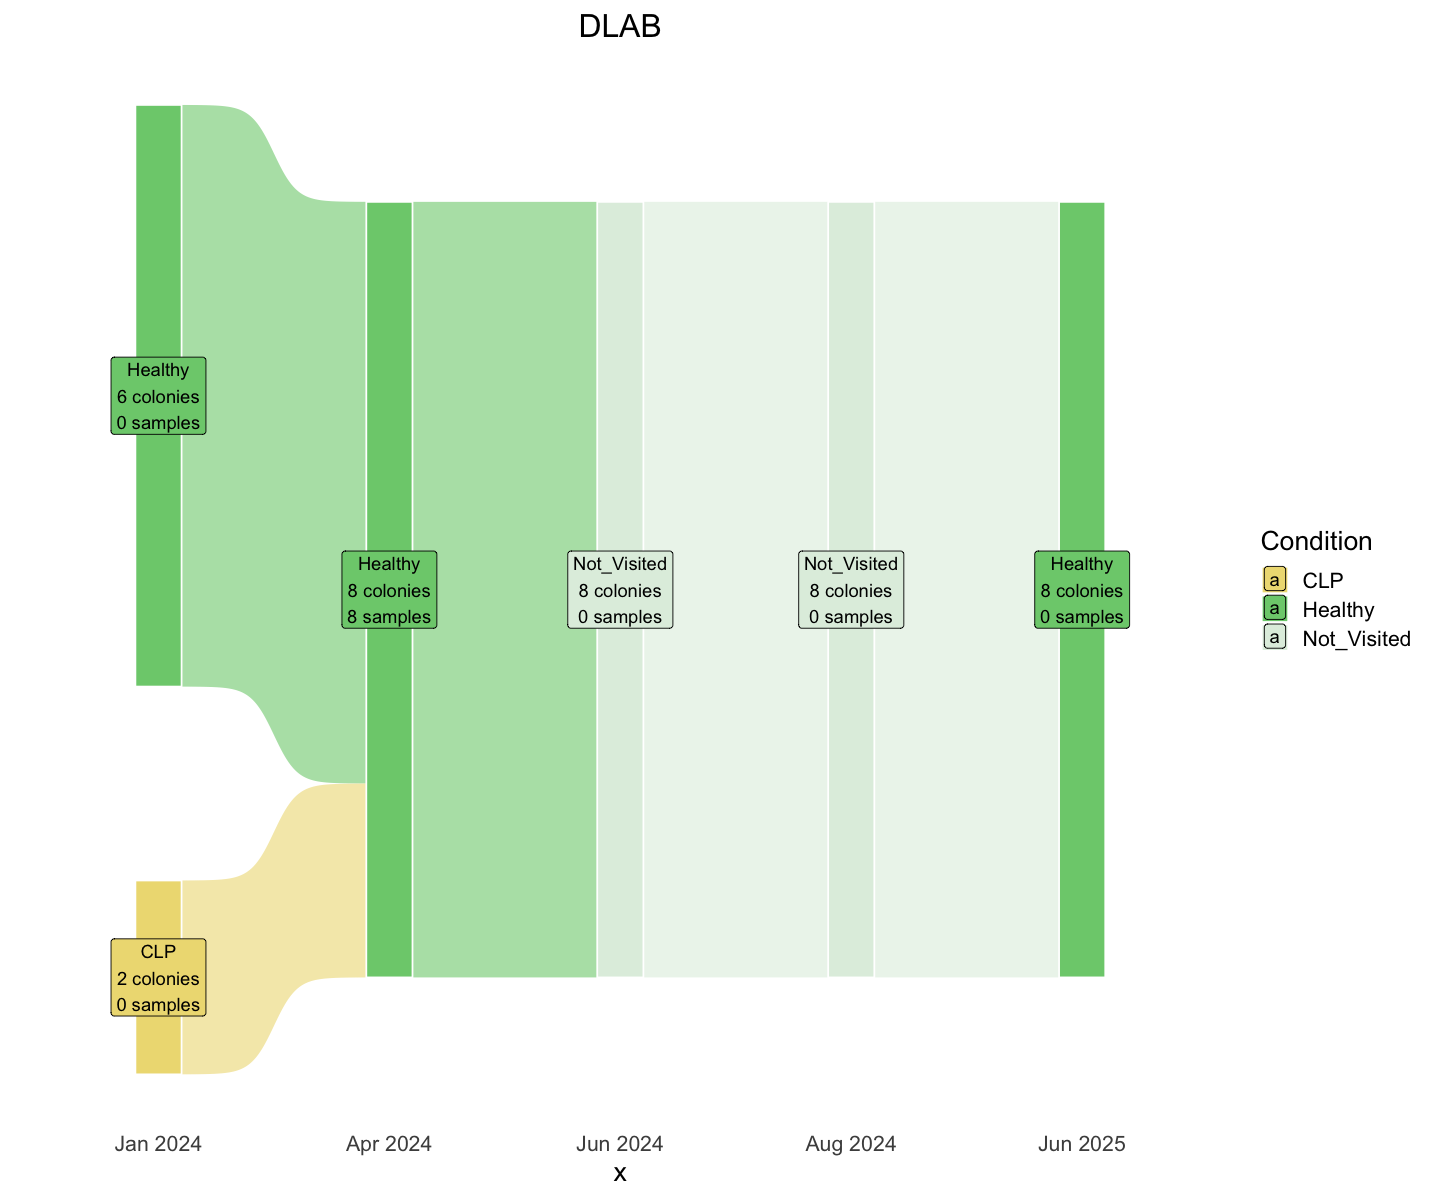

[1] "Missing samples:"
# A tibble: 16 × 4
   colony_id   x        node    `immune_y/n`
   <chr>       <fct>    <chr>   <chr>       
 1 T2_29_OFAV  Jan 2024 Healthy n           
 2 T2_29_OFAV  Jun 2025 Healthy n           
 3 T2_76_OFAV  Jun 2025 Healthy y           
 4 T2_79_OFAV  Jun 2025 Healthy y           
 5 T2_80_OFAV  Jan 2024 CLP     n           
 6 T2_80_OFAV  Jun 2025 Healthy n           
 7 T3_38_OFAV  Aug 2024 Healthy y           
 8 T3_38_OFAV  Jun 2025 Healthy y           
 9 T3_39_OFAV  Jun 2025 Healthy y           
10 T4_77_OFAV  Jan 2024 Healthy n           
11 T4_77_OFAV  Jun 2025 Healthy n           
12 T4_78_OFAV  Jun 2025 Healthy y           
13 T4_92_OFAV  Jan 2024 Healthy n           
14 T4_92_OFAV  Jun 2025 Healthy n           
15 T4_100_OFAV Jan 2024 Healthy n           
16 T4_100_OFAV Jun 2025 Healthy n           


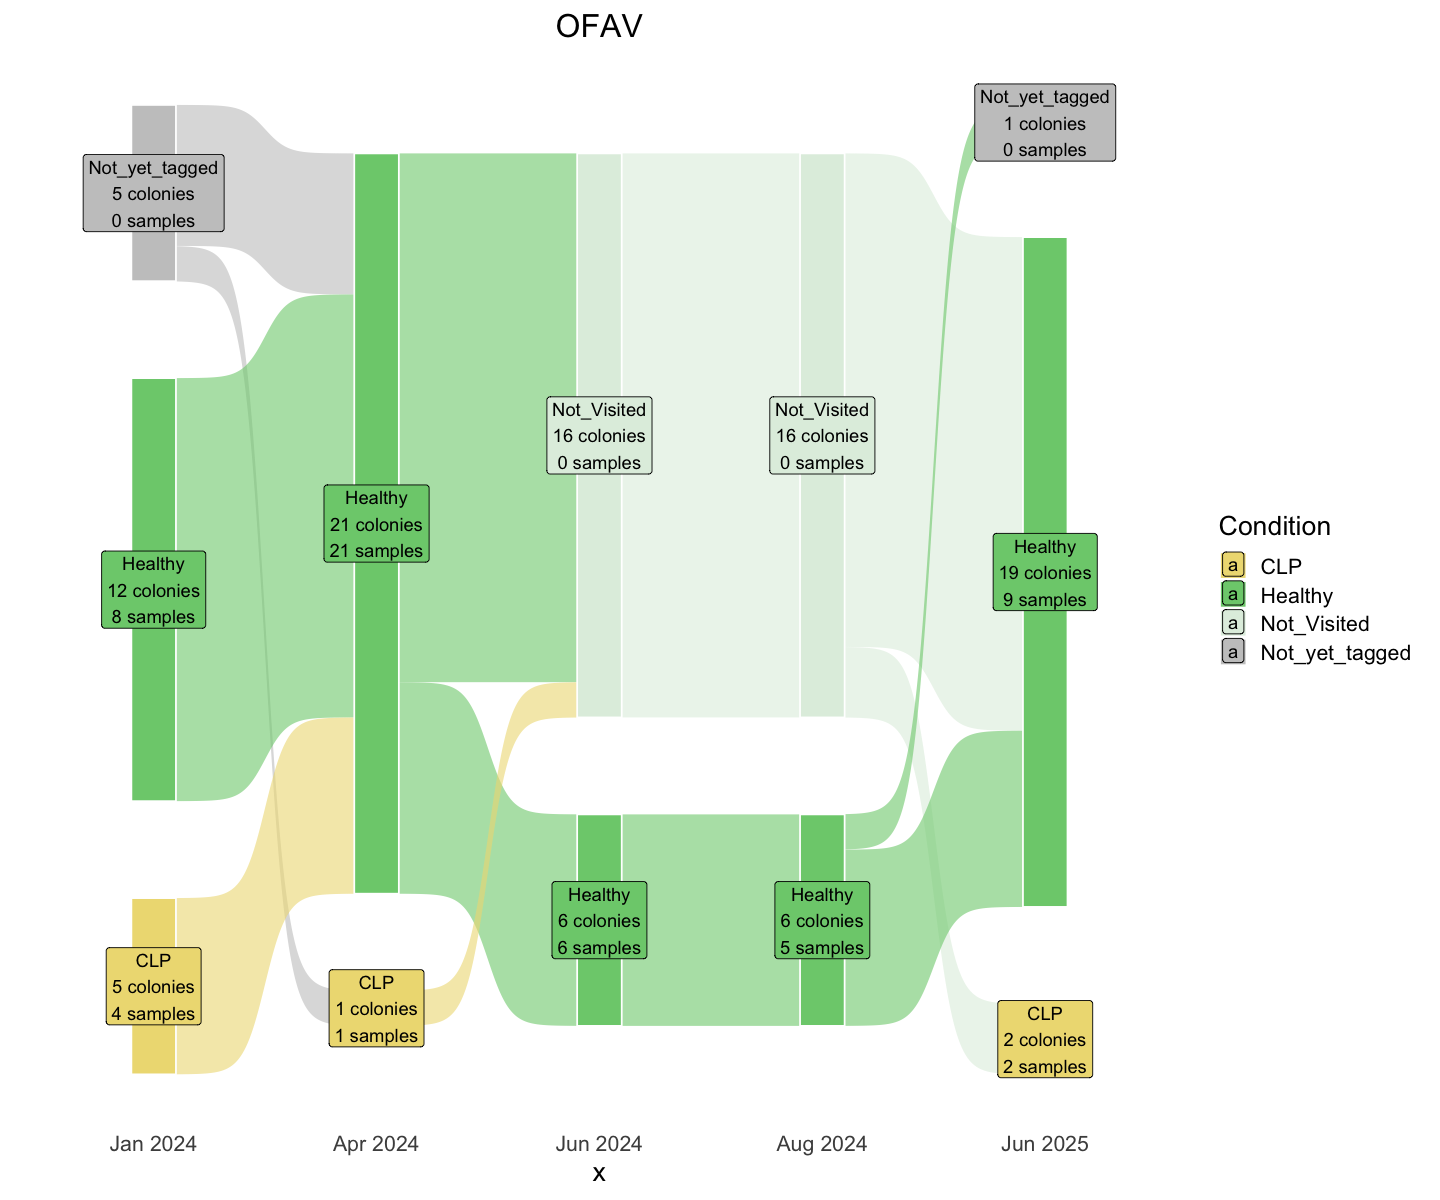

In [99]:
# plot all
species_list<-unique(sankey$species)

for (specie in species_list){
    df <-sankey %>%
        filter(species == specie)

    # for each node type, how many samples are there  
    df_count <- df %>%
      group_by(x, node) %>%
            # sum colonies per node & time point (x)
      mutate(colony_count = n(),
             # sum samples per node and time point grouping 
             n_samples = sum(!is.na(sample_condition), na.rm = TRUE),
             label_text = paste0(node, "\n", 
                            colony_count, " colonies\n",
                            n_samples, " samples")
            ) %>% 
    ungroup()

    # make list of missing samples 
    missing_samples_list<-df_count %>%
    # exclude dead, not visited conditions since those are never sampled 
      filter(!node %in% c('Dead', 'Not_Visited', 'Not_yet_tagged')) %>%
    # if condition count != sample count, print colony ID that has NA as sample_condition (wasn't sampled) 
      filter(colony_count != n_samples & is.na(sample_condition)) %>%
        # exclude non-immune corals during immune sample dates
      # filter(!(x %in% immune_dates & `immune_y/n` == 'n')) %>% 
      select(colony_id, x, node, `immune_y/n`)
    
    # if storing missing samples as a df (add in..)
      # mutate(missing_samples = paste(x,node, sep = " | ")) %>%
      # pull(missing_samples, colony_id)

    # plot
    plot<-ggplot(df_count, aes(x = x, next_x = next_x,
                        node = node, next_node = next_node,
                        fill = factor(node))) +
    geom_sankey(flow.alpha = 0.6, node.color = "white", width = 0.2) +
    geom_sankey_label(aes(label = label_text)) +
    scale_fill_manual("Condition", values = sank_colors) +
    theme_sankey(base_size = 16) +
    theme(plot.title = element_text(hjust = 0.5))+
    ggtitle(paste(specie))
    
    print(plot)
    
# print if there are missing samples
    # if missing_samples tibble has any rows, print them 
    if (nrow(missing_samples_list) > 0) {
      print("Missing samples:")
      print(missing_samples_list)
    }
    }

# ssid looks like theres 1 sample that was not visited the whole time.. maybe it was previously dead 
# 1 mcav called diseased then diseased_other -> should probably just make this consistent 
# pstr - in april we have 23 colonies, but in the rest of the dates we only have 21?

In [20]:
# maybe add in 2025 since some of these are non-immune and we don't have fates for them in aug?